In [1]:
from datasets import load_dataset

ds = load_dataset("papluca/language-identification")

d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shawk\.cache\huggingface\hub\datasets--papluca--language-identification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order 

In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

# EDA

In [3]:
ds["train"][0]

{'labels': 'pt',
 'text': 'os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.'}

In [10]:
import pandas as pd 

train_ds = pd.DataFrame(ds["train"].shuffle(seed=42))
validation_ds = pd.DataFrame(ds["validation"].shuffle(seed=42))
test_ds = pd.DataFrame(ds["test"])

In [11]:
train_ds.head()

,labels,text
0,pl,mld . Wszyscy na świecie na obecnym poziomie d...
1,tr,Bana mesaj var mı ?
2,en,"I am allergic to cocoa, and dairy and gluten. ..."
3,tr,"Güçlü bir başarı oldu , güç nesli ' nden gelen..."
4,vi,"Đối với tất cả sự vĩ đại lịch sử của nó , thượ..."


In [12]:
train_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   labels  70000 non-null  str  
 1   text    70000 non-null  str  
dtypes: str(2)
memory usage: 12.3 MB


In [21]:
train_ds["labels"].value_counts()

labels
pl    3500
tr    3500
en    3500
vi    3500
zh    3500
ru    3500
th    3500
bg    3500
el    3500
pt    3500
es    3500
ur    3500
nl    3500
ar    3500
fr    3500
de    3500
sw    3500
ja    3500
it    3500
hi    3500
Name: count, dtype: int64

In [15]:
pd.set_option('display.max_colwidth', None)

In [17]:
filter = train_ds["labels"] == "ar"
train_ds[filter].head(20)

,labels,text
19,ar,لا فائدة من الرد على ان القانون نفسه يحمي الخصوصية افضل من حقوق التاليف والنشر يحمي فيلم سبيلبرغ .
65,ar,ما هو مفتوح لك .
71,ar,هل لديه مشكلة مع نوعية اليهود الذين يتم انتاجه في امريكا اليوم ?
105,ar,"و يحاول محلل دراسة الحالة ان يبني وصفا دقيقا للاحداث وشرح لها , حيث ان كل من المراقبين والمشاركين اطارها ."
113,ar,"وبالتالي , فان العقوبات المفروضة على الضرائب الجانحين هي ايرادات غير قابلة للت nonexchange ."
123,ar,ال اثنان الوحيدتين مع اي نوع من الضربه هي الانسة امريكا -- و a بشكل مدهش بات بيوكانان -- والانسة المانيا --
160,ar,"ولن يكتمل اي حساب لهذه المنطقة بدون قصة nichiren ( 1222 1282 ) , الراهب الذي اسس الطائفة اليابانية الوحيدة من البوذية ."
170,ar,عندما ذهبنا الى مكان ما ولكن حقا وفي الحقيقة ميزات الامان ولكن لن احصل على واحدة اذا كان لديها حزام الامان على الباب الان انا لن احصل عليه فترة
181,ar,فهمت ماذا ?
217,ar,اوه lewisville اي طعام محترم فيتك فوق هناك


# Preprocessing

In [22]:
import re

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove Arabic diacritics
    arabic_diacritics = re.compile(r"[\u064B-\u0652]")
    text = re.sub(arabic_diacritics, "", text)
    
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()
    
    return text

In [23]:
sample_text = "Check out this AI tool! https://google.com #NLP المَغْرِبُ @user"
print("Text before cleaning:", sample_text)
print("Text after cleaning:", clean_text(sample_text))

Text before cleaning: Check out this AI tool! https://google.com #NLP المَغْرِبُ @user
Text after cleaning: check out this ai tool! المغرب


In [24]:
X_train = train_ds["text"].apply(clean_text)
y_train = train_ds["labels"]

X_validation = validation_ds["text"].apply(clean_text)
y_validation = validation_ds["labels"]

X_test = test_ds["text"].apply(clean_text)
y_test = test_ds["labels"]

In [26]:
X_train.head()

0                                                                                                                                                          mld . wszyscy na świecie na obecnym poziomie dobrobytu w meksyku.
1                                                                                                                                                                                                        bana mesaj var mı ?
2               i am allergic to cocoa, and dairy and gluten. finding this bar was a chocolate lovers dream! it really tastes like a chocolate bar! to be sure, i had a chocolate eating friend try it and she liked it too.
3                                güçlü bir başarı oldu , güç nesli ' nden gelen so2 emisyonları 1990 seviyeleri 4.5 milyon ton ve nox emi̇syonlari 1990 milyon ton aşağı düştü ( yaklaşık 3 milyon ton daha düşük büyüme ) .
4    đối với tất cả sự vĩ đại lịch sử của nó , thượng viện trung thành bây giờ là tương đương với hội đồng thành phố

# Modeling

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import time

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 5),
        max_features=50000
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

In [28]:
start_time = time.time()
pipeline.fit(X_train, y_train)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")

d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training completed in 85.68 seconds.


In [31]:
test_sentences = [
    "مرحبا بك في عالم الذكاء الاصطناعي", 
    "Hello and welcome to the new project", 
    "Bonjour tout le monde",                
    "こんにちは"                             
]

predictions = pipeline.predict(test_sentences)

for text, lang in zip(test_sentences, predictions):
    print(f" Text: '{text}' --->  Pred: [{lang}]")

 Text: 'مرحبا بك في عالم الذكاء الاصطناعي' --->  Pred: [ar]
 Text: 'Hello and welcome to the new project' --->  Pred: [en]
 Text: 'Bonjour tout le monde' --->  Pred: [fr]
 Text: 'こんにちは' --->  Pred: [zh]


## Validation

In [32]:
val_predictions = pipeline.predict(X_validation)

from sklearn.metrics import classification_report
print(classification_report(y_validation, val_predictions))

              precision    recall  f1-score   support

          ar       1.00      0.99      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.98      1.00      0.99       500
          es       1.00      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.95      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       0.98      1.00      0.99       500
          pl       1.00      1.00      1.00       500
          pt       0.99      1.00      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.95      1.00      0.97       500
          th       1.00      0.99      0.99       500
          tr       0.99      1.00      1.00       500
          ur       1.00    

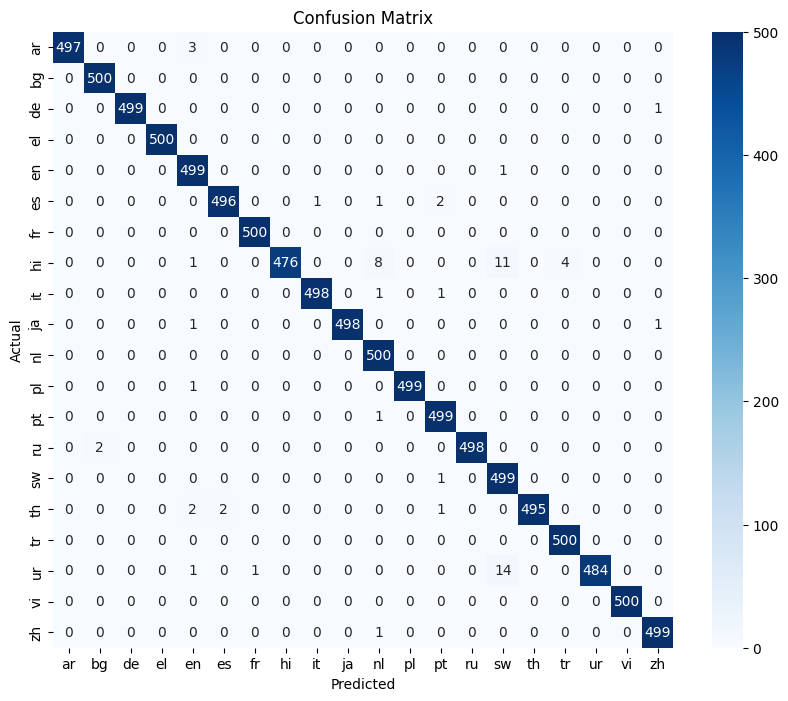

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm  = confusion_matrix(y_validation, val_predictions, labels=pipeline.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Testing on test set

In [34]:
test_predictions = pipeline.predict(X_test) 

print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.99      1.00      1.00       500
          es       0.99      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       0.99      0.99      0.99       500
          ja       1.00      1.00      1.00       500
          nl       1.00      0.99      0.99       500
          pl       1.00      0.99      0.99       500
          pt       0.99      0.98      0.98       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      0.99      1.00       500
          tr       0.99      1.00      1.00       500
          ur       1.00    

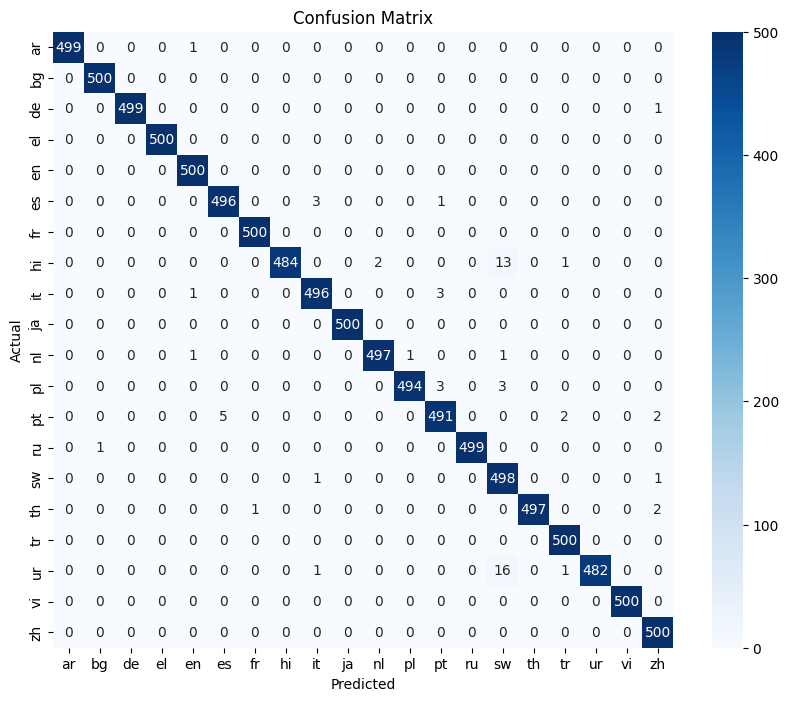

In [35]:
cm  = confusion_matrix(y_test, test_predictions, labels=pipeline.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Saving

In [38]:
import joblib

joblib.dump(pipeline, "../trained_models/language_identification_model.pkl")

['../trained_models/language_identification_model.pkl']

In [39]:
start = time.time()
test_sentences = [
    "مرحبا بك في عالم الذكاء الاصطناعي", 
    "Hello and welcome to the new project", 
    "Bonjour tout le monde",                
    "こんにちは"                             
]

predictions = pipeline.predict(test_sentences)

for text, lang in zip(test_sentences, predictions):
    print(f" Text: '{text}' --->  Pred: [{lang}]")

end = time.time()
print(f"Time taken: {end - start} seconds")

 Text: 'مرحبا بك في عالم الذكاء الاصطناعي' --->  Pred: [ar]
 Text: 'Hello and welcome to the new project' --->  Pred: [en]
 Text: 'Bonjour tout le monde' --->  Pred: [fr]
 Text: 'こんにちは' --->  Pred: [zh]
Time taken: 0.0064046382904052734 seconds
